In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, welch, iirnotch

# تنظیمات نمایش پلات‌ها
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

FS = 300  # Sampling frequency in PhysioNet 2017 dataset is 300 Hz


In [2]:
def butter_bandpass(lowcut=0.5, highcut=45.0, fs=FS, order=4):
    """طراحی فیلتر میان‌گذر باترورث"""
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_bandpass_filter(signal, lowcut=0.5, highcut=45.0, fs=FS, order=4):
    """اعمال فیلتر بدون شیفت فاز با filtfilt"""
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    # filtfilt فیلتر رفت و برگشتی اعمال می‌کند تا تاخیر فاز صفر شود
    filtered = filtfilt(b, a, signal)
    return filtered

def apply_notch_filter(signal, notch_freq=50.0, fs=FS, Q=30.0):
    """حذف نویز برق شهر"""
    nyquist = 0.5 * fs
    freq = notch_freq / nyquist
    b, a = iirnotch(freq, Q)
    return filtfilt(b, a, signal)

def full_ecg_denoise(signal, fs=FS):
    """پایپ‌لاین کامل حذف نویز"""
    sig_bp = apply_bandpass_filter(signal, lowcut=0.5, highcut=45.0, fs=fs)
    sig_clean = apply_notch_filter(sig_bp, notch_freq=50.0, fs=fs)
    return sig_clean


In [3]:
# مسیر یک فایل نمونه با نویز Baseline Wander یا نویز فرکانس بالا
# مسیر را در صورت نیاز با فولدرهای دیتای خود هماهنگ کنید
sample_path = r"../data/raw/A00/A00001.mat"  # یا مسیر dataset/raw_data

mat_data = loadmat(sample_path)
raw_ecg = mat_data['val'][0].astype(np.float32)

# اعمال فیلتر
clean_ecg = full_ecg_denoise(raw_ecg, fs=FS)

print(f"Raw ECG shape: {raw_ecg.shape}")
print(f"Sampling Rate: {FS} Hz | Duration: {len(raw_ecg)/FS:.2f} seconds")


Raw ECG shape: (9000,)
Sampling Rate: 300 Hz | Duration: 30.00 seconds


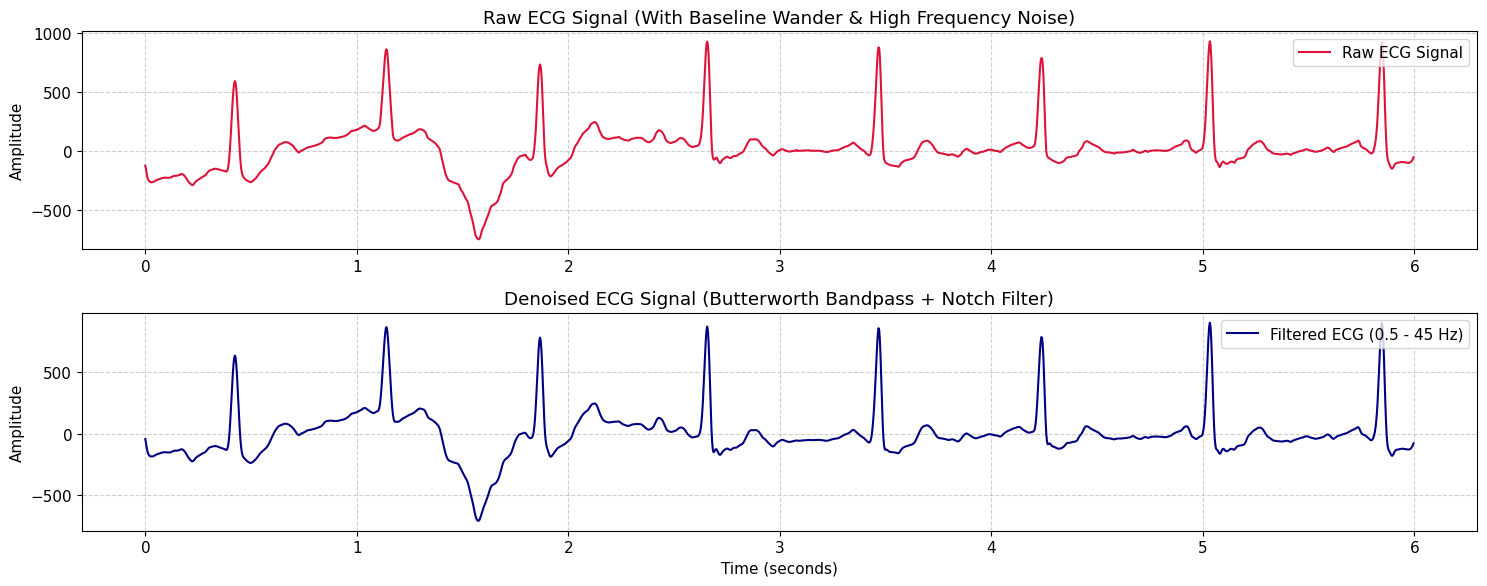

In [4]:
# نمایش ۵ ثانیه اول سیگنال
time_axis = np.arange(len(raw_ecg)) / FS
plot_samples = FS * 6  # ۶ ثانیه اول

plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
plt.plot(time_axis[:plot_samples], raw_ecg[:plot_samples], color='crimson', label='Raw ECG Signal')
plt.title("Raw ECG Signal (With Baseline Wander & High Frequency Noise)")
plt.ylabel("Amplitude")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

plt.subplot(2, 1, 2)
plt.plot(time_axis[:plot_samples], clean_ecg[:plot_samples], color='navy', label='Filtered ECG (0.5 - 45 Hz)')
plt.title("Denoised ECG Signal (Butterworth Bandpass + Notch Filter)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


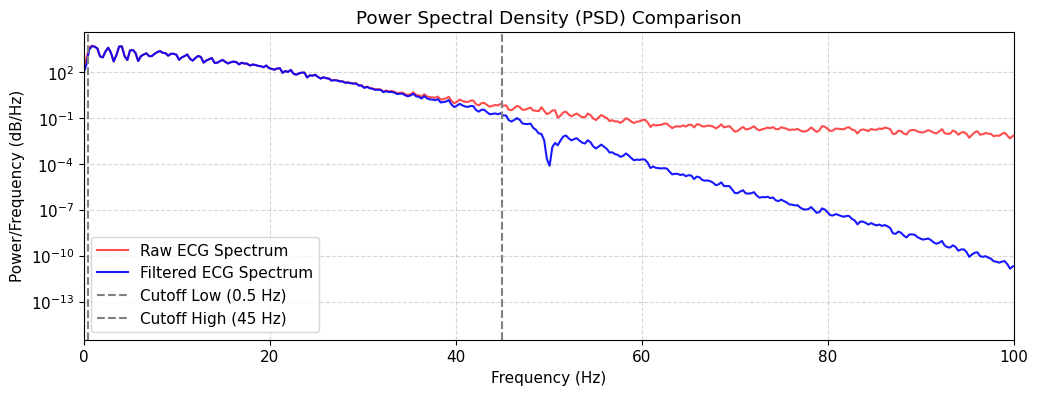

In [5]:
freqs_raw, psd_raw = welch(raw_ecg, fs=FS, nperseg=1024)
freqs_clean, psd_clean = welch(clean_ecg, fs=FS, nperseg=1024)

plt.figure(figsize=(12, 4))
plt.semilogy(freqs_raw, psd_raw, label='Raw ECG Spectrum', color='red', alpha=0.7)
plt.semilogy(freqs_clean, psd_clean, label='Filtered ECG Spectrum', color='blue', alpha=0.9)
plt.axvline(0.5, color='gray', linestyle='--', label='Cutoff Low (0.5 Hz)')
plt.axvline(45.0, color='gray', linestyle='--', label='Cutoff High (45 Hz)')
plt.title("Power Spectral Density (PSD) Comparison")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power/Frequency (dB/Hz)")
plt.xlim(0, 100)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()


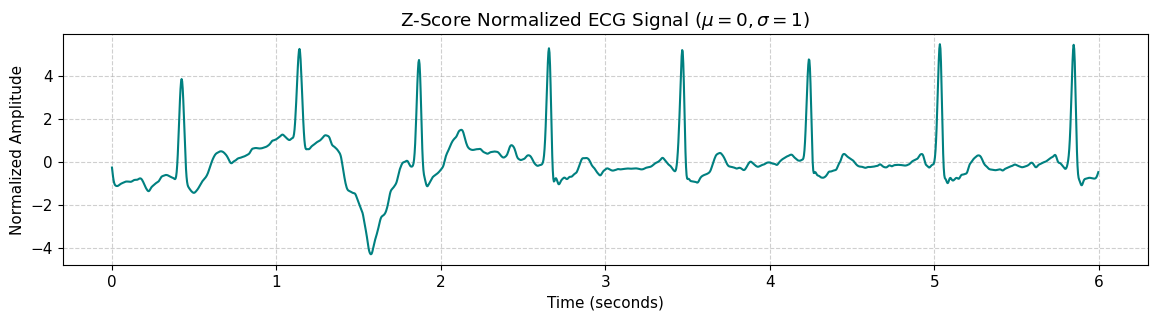

In [6]:
def zscore_normalize(signal):
    """نرمال‌سازی استاندارد Z-score با میانگین ۰ و واریانس ۱"""
    mean = np.mean(signal)
    std = np.std(signal)
    if std == 0:
        return signal - mean
    return (signal - mean) / std

def minmax_normalize(signal):
    """نرمال‌سازی در بازه [0, 1] یا [-1, 1]"""
    min_v = np.min(signal)
    max_v = np.max(signal)
    if max_v - min_v == 0:
        return signal
    return 2 * (signal - min_v) / (max_v - min_v) - 1

norm_ecg = zscore_normalize(clean_ecg)

plt.figure(figsize=(14, 3))
plt.plot(time_axis[:plot_samples], norm_ecg[:plot_samples], color='teal')
plt.title("Z-Score Normalized ECG Signal ($\mu=0, \sigma=1$)")
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Amplitude")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Total detected R-peaks: 42
Mean Heart Rate: 83.3 BPM
RR Interval Std Dev (RRV / RMSSD indicator): 110.88 ms


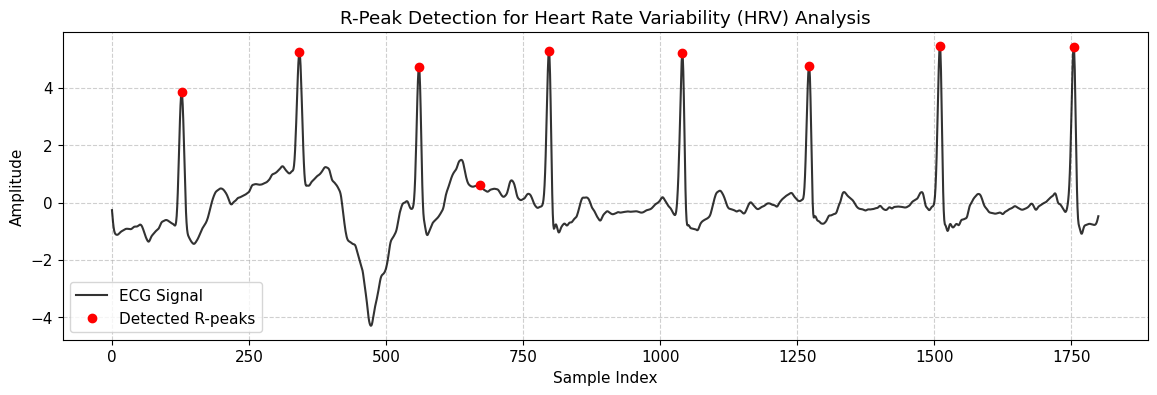

In [7]:
from scipy.signal import find_peaks

# تشخیص تقریبی قله‌های R (R-Peaks) با آستانه‌گذاری فاصله و دامنه
# فاصله حداقل بین دو ضربان در انسان معمولاً بیش از ۰.۲۵ ثانیه است (FS * 0.25)
min_distance = int(FS * 0.3)  # حداقل 90 نمونه
height_thresh = np.percentile(norm_ecg, 85)  # پیک‌های بالاتر از صدک 85

peaks, _ = find_peaks(norm_ecg, distance=min_distance, height=height_thresh)

# محاسبه فواصل RR بر حسب میلی‌ثانیه
rr_intervals = np.diff(peaks) / FS * 1000  # ms

print(f"Total detected R-peaks: {len(peaks)}")
print(f"Mean Heart Rate: {60 / (np.mean(rr_intervals) / 1000):.1f} BPM")
print(f"RR Interval Std Dev (RRV / RMSSD indicator): {np.std(rr_intervals):.2f} ms")

# رسم تشخیص R-peaks روی سیگنال
plt.figure(figsize=(14, 4))
plt.plot(norm_ecg[:plot_samples], label='ECG Signal', color='black', alpha=0.8)
plot_peaks = [p for p in peaks if p < plot_samples]
plt.plot(plot_peaks, norm_ecg[plot_peaks], "ro", label='Detected R-peaks')
plt.title("R-Peak Detection for Heart Rate Variability (HRV) Analysis")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [8]:
def preprocess_ecg_record(raw_signal, target_length=9000, fs=FS):
    """
    پایپ‌لاین کامل آماده‌سازی یک سیگنال برای ورودی مدل:
    1. حذف نویز (Bandpass 0.5-45 Hz)
    2. حذف نویز برق (Notch 50 Hz)
    3. نرمال‌سازی Z-Score
    4. یکسان‌سازی طول به 30 ثانیه (9000 نمونه) با Zero-padding یا Truncation
    """
    # 1 & 2. Denoise
    clean = full_ecg_denoise(raw_signal, fs=fs)
    
    # 3. Normalize
    norm = zscore_normalize(clean)
    
    # 4. Fix length (Padding / Truncate)
    if len(norm) > target_length:
        processed = norm[:target_length]
    else:
        pad_width = target_length - len(norm)
        processed = np.pad(norm, (0, pad_width), mode='constant', constant_values=0)
        
    return processed.astype(np.float32)

# تست تابع روی یک نمونه
test_out = preprocess_ecg_record(raw_ecg)
print("Final preprocessed input shape for DL models:", test_out.shape)


Final preprocessed input shape for DL models: (9000,)
